# Exercice 3 - Remplacez la Q-table par un cerveau neuronal (DQN)
## Etape 1 : Création et test des classes utilitaires

### Introduction
Les classes sont décrites dans le fichier `./lib.py` : 

* `lib.DQN`: Réseau de neuronnes PyTorch pour effectuer l'expérience et la prise de décision (fonction Q), initialisé avec plusieurs couches + fonction d'ativation
* `lib.ReplayBuffer` : mémoire pour les expériences avec le réseau de neuronnes
  * push() : ajoute une expérience au buffer
  * sample(): extrait un batch aléatoire d'expériences mémorisées

### Test des classes utilitaires

In [1]:
import lib
import torch

# Paramètres pour CartPole-v1
state_size = 4  # CartPole a 4 observations
action_size = 2  # CartPole a 2 actions (gauche/droite)

# Instanciation du DQN
dqn = lib.DQN(state_size, action_size, hidden_size=128)

# Affichage de l'architecture
print("Architecture du DQN:")
print(dqn)
print("\n" + "="*50 + "\n")

# Test avec un état fictif
test_state = torch.randn(1, state_size) # batch_size = 1
q_values = dqn(test_state)
print(f"État de test: {test_state}")
print(f"Valeurs Q prédites: {q_values}")
print(f"Action choisie (argmax): {q_values.argmax().item()}")
print("\n" + "="*50 + "\n")

# Instanciation du ReplayBuffer (avec 10 000 expériences)
buffer = lib.ReplayBuffer(capacity=10000)

# Ajout de quelques expériences fictives
for i in range(50):
    state = [0.1 * i, 0.2 * i, 0.3 * i, 0.4 * i]
    action = i % 2 # modulo pour alterner avec 0, 1 (gauche et droite)
    reward = 1.0
    next_state = [0.1 * (i+1), 0.2 * (i+1), 0.3 * (i+1), 0.4 * (i+1)]
    done = False
    buffer.push(state, action, reward, next_state, done)

print(f"Taille du buffer: {len(buffer)}")

# Échantillonnage d'un batch
if len(buffer) >= 10:
    states, actions, rewards, next_states, dones = buffer.sample(10)
    print(f"\nBatch échantillonné (taille 10):")
    print(f"États: {states}")
    print(f"Actions: {actions}")
    print(f"Récompenses: {rewards}")


Architecture du DQN:
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


État de test: tensor([[ 1.1265,  2.8385,  0.2829, -0.5918]])
Valeurs Q prédites: tensor([[-0.0079, -0.0489]], grad_fn=<AddmmBackward0>)
Action choisie (argmax): 0


Taille du buffer: 50

Batch échantillonné (taille 10):
États: [[1.7000000000000002, 3.4000000000000004, 5.1, 6.800000000000001], [2.7, 5.4, 8.1, 10.8], [4.7, 9.4, 14.1, 18.8], [3.3000000000000003, 6.6000000000000005, 9.9, 13.200000000000001], [4.4, 8.8, 13.2, 17.6], [0.7000000000000001, 1.4000000000000001, 2.1, 2.8000000000000003], [1.3, 2.6, 3.9, 5.2], [0.1, 0.2, 0.3, 0.4], [0.6000000000000001, 1.2000000000000002, 1.7999999999999998, 2.4000000000000004], [3.6, 7.2, 10.799999999999999, 14.4]]
Actions: [1, 1, 1, 1, 0, 1, 1, 1, 0, 0]
Récompenses: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Etape 2 : Boucle d'entrainement DQN

Épisode 50/600, Récompense: 8.0
Épisode 100/600, Récompense: 12.0
Épisode 150/600, Récompense: 10.0
Épisode 200/600, Récompense: 23.0
Épisode 250/600, Récompense: 140.0
Épisode 300/600, Récompense: 123.0
Épisode 350/600, Récompense: 139.0
Épisode 400/600, Récompense: 116.0
Épisode 450/600, Récompense: 122.0
Épisode 500/600, Récompense: 113.0
Épisode 550/600, Récompense: 105.0
Épisode 600/600, Récompense: 97.0
Entraînement complet


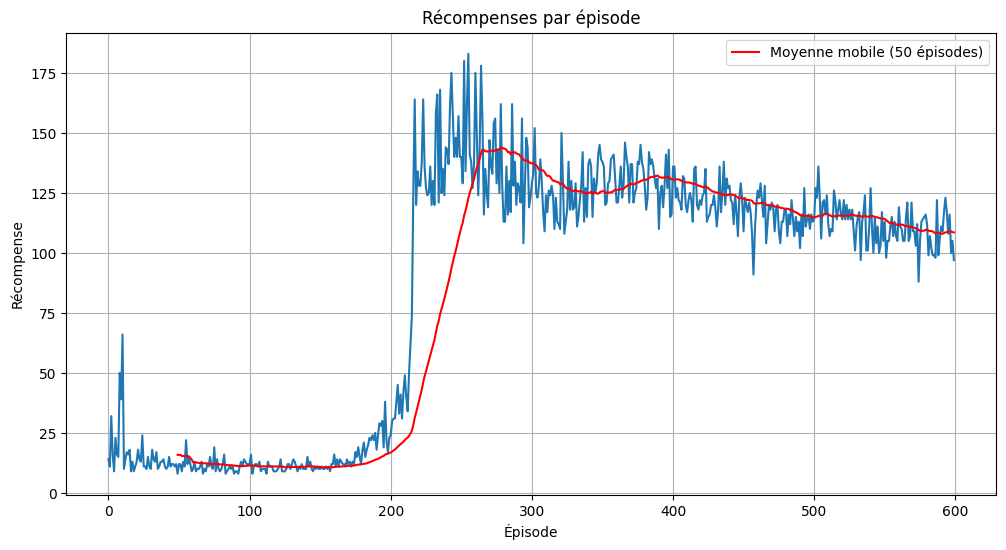

In [8]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Use a GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparamètres
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000
TARGET_UPDATE = 10
LR = 1e-4
BUFFER_CAPACITY = 10000
NUM_EPISODES = 600

# Initialisation
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = lib.DQN(state_dim, action_dim).to(device)
target_net = lib.DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Mettre le target_net en mode évaluation

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = lib.ReplayBuffer(BUFFER_CAPACITY)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) returns largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    batch = memory.sample(BATCH_SIZE)
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)

    # Convertir en tenseurs PyTorch
    states = torch.FloatTensor(np.array(states)).to(device)
    # --- CORRECTION ---
    # `action` est un tuple de scalaires (ex: (0, 1, 1, 0...)).
    # On le convertit en tenseur puis on lui ajoute une dimension pour qu'il ait la forme [BATCH_SIZE, 1]
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)

    # Masque pour les états non-finaux (ceux où l'épisode n'est pas terminé)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          next_states)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([torch.FloatTensor(s).unsqueeze(0) for s in next_states if s is not None]).to(device)

    # Calculer Q(s, a) : Le réseau calcule Q(s), puis nous sélectionnons les colonnes des actions effectuées
    # --- LA LIGNE QUI POSAIT PROBLÈME, MAINTENANT CORRIGÉE ---
    q_values = policy_net(states).gather(1, actions)

    # Calculer V(s') pour tous les prochains états.
    next_q_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_q_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]

    # Calculer la valeur Q cible (expected Q values)
    expected_q_values = (next_q_values * GAMMA) + rewards

    # Calculer la perte (loss)
    criterion = nn.SmoothL1Loss()
    loss = criterion(q_values, expected_q_values.unsqueeze(1))

    # Optimiser le modèle
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100) # Clipper le gradient pour la stabilité
    optimizer.step()

# Boucle d'entraînement principale
episode_rewards = []
for i_episode in range(NUM_EPISODES):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0

    terminated, truncated = False, False
    while not terminated and not truncated:
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        total_reward += reward
        done = terminated or truncated

        # --- CORRECTION ---
        # Si l'épisode est terminé, `next_state` est `None`.
        # Sinon, c'est l'observation.
        if done:
            next_state = None
        else:
            next_state = observation

        # Stocker la transition dans la mémoire.
        # On stocke des objets simples (vecteurs et scalaires numpy/python), pas des tenseurs.
        # `action.item()` extrait la valeur scalaire de l'action.
        memory.push(state.squeeze(0).cpu().numpy(), action.item(), reward, next_state, done)

        # Passer à l'état suivant
        if next_state is not None:
            state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
        else:
            state = None

        # Effectuer une étape d'optimisation
        optimize_model()

        if done:
            break

    episode_rewards.append(total_reward)

    # Mettre à jour le target network
    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (i_episode + 1) % 50 == 0:
      print(f"Épisode {i_episode+1}/{NUM_EPISODES}, Récompense: {total_reward}")

print('Entraînement complet')
env.close()

# Afficher les résultats
plt.figure(figsize=(12,6))
plt.plot(episode_rewards)
plt.title('Récompenses par épisode')
plt.xlabel('Épisode')
plt.ylabel('Récompense')
# Calculer et afficher une moyenne mobile pour mieux voir la tendance
if len(episode_rewards) >= 50:
    moving_avg = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
    plt.plot(np.arange(len(moving_avg)) + 49, moving_avg, color='red', label='Moyenne mobile (50 épisodes)')
plt.legend()
plt.grid(True)
plt.show()